In [1]:
!pip install --quiet accelerate
!pip install --quiet bitsandbytes
!pip install --quiet datasets
!pip install --quiet -U ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 22.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 23.1 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [3]:
import transformers
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, GenerationConfig
from huggingface_hub import hf_hub_download, login

import torch
from torch import Tensor, nn

import numpy as np

import math
import json
import random
import zlib
import base64
import ast
import tokenize
import itertools
import io
import re
import gc
import pickle

import pandas as pd

from abc import ABC, abstractmethod
from dataclasses import dataclass, field, asdict
from pydantic import BaseModel, ValidationError
from typing import List, Dict, Any, Optional
from tqdm import tqdm
import json

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
hf_token = ''

In [7]:
login(token=hf_token)

In [8]:
%%writefile eval_dto.py
from pydantic import BaseModel, Field
from typing import List, Dict, Any, Optional
import numpy as np
import scipy.special

class Stats(BaseModel):
    all_stats: List[Dict]  = Field(default_factory=list)
    best_stats: Dict = Field(default_factory=lambda: {'correct': False, 'score': 0.0, 'reward': 0.0, 'completion': ""})
    
    def add(self, stats):
        self.all_stats.append(stats)
        if stats['reward'] > self.best_stats['reward']:
            self.best_stats = stats

    # As ORM is not GT verifier, reward going up does not always translate into higher accuracy
    # Such variant allows to see whether this result in model deceiving the ORM or finiding consistent strategy 
    def pass_k_orm(self, k):
        current_stats = self.all_stats[:k]
        current_best = max(current_stats, key=lambda s: s['reward'])

        return 1.0 if current_best['correct'] else 0.0

    def pass_k_noisy(self, k):
        c = len([s for s in self.all_stats[:k] if s['correct']])

        return 1.0 if c > 0 else 0.0

    def rm_k(self, k):
        rm_scores = np.array([s['reward'] for s in self.all_stats])
        gt_labels = np.array([s['correct'] for s in self.all_stats])
        N = len(rm_scores)

        sort_indices = np.argsort(rm_scores)[::-1]
        sorted_gt = gt_labels[sort_indices]
            
        j = np.arange(N)
        worse_items = N - 1 - j
        results = {}
        
        ways_to_be_best = scipy.special.comb(worse_items, k - 1, exact=False)
        total_combinations = scipy.special.comb(N, k, exact=False)
        expected_pass = np.sum(sorted_gt * ways_to_be_best) / total_combinations if total_combinations > 0 else 0.0

        return expected_pass
        
    def pass_k(self, k):
        n = len(self.all_stats)
        c = len([s for s in self.all_stats if s['correct']])
    
        if n - c < k:
            return 1.0
        
        return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

class TaskState(BaseModel):
    task_id: str
    task_data: Any
    conversation: List[Dict[str, str]] = Field(default_factory=list)
    agent_states: Optional[List[Any]] = None
    attempts: int = 0
    is_done: bool = False
    stats: Stats = Field(default_factory=dict)

class BenchmarkResults(BaseModel):
    items: List[TaskState]
    metadata: Dict[str, Any]

Writing eval_dto.py


In [9]:
from eval_dto import *

Trajectories are shared publicly on [kaggle](https://www.kaggle.com/datasets/oleksiistreltsov/fleet-full-trajectories)

In [10]:
file_paths = {
    'gsm8k_fleet_gt': f'/kaggle/input/datasets/oleksiistreltsov/fleet-full-trajectories/Llama-3.2-3B-Instruct (gsm8k_fleet_gt).json',
    'gsm8k_fleet_orm': f'/kaggle/input/datasets/oleksiistreltsov/fleet-full-trajectories/Llama-3.2-3B-Instruct (gsm8k_fleet_orm).json',
    'gsm8k_sampling_gt': f'/kaggle/input/datasets/oleksiistreltsov/fleet-full-trajectories/Llama-3.2-3B-Instruct (gsm8k_sampling_gt).json',
    'gsm8k_sampling_orm': f'/kaggle/input/datasets/oleksiistreltsov/fleet-full-trajectories/Llama-3.2-3B-Instruct (gsm8k_sampling_orm).json',
    'lcb_fleet_gt': f'/kaggle/input/datasets/oleksiistreltsov/fleet-full-trajectories/Llama-3.2-3B-Instruct (lcb_fleet_gt).json',
    'lcb_fleet_orm': f'/kaggle/input/datasets/oleksiistreltsov/fleet-full-trajectories/Llama-3.2-3B-Instruct (lcb_fleet_orm).json',
    'lcb_sampling_gt': f'/kaggle/input/datasets/oleksiistreltsov/fleet-full-trajectories/Llama-3.2-3B-Instruct (lcb_sampling_gt).json',
    'lcb_sampling_orm': f'/kaggle/input/datasets/oleksiistreltsov/fleet-full-trajectories/Llama-3.2-3B-Instruct (lcb_sampling_orm).json',
}

def get_results(file_paths):
    def parse_results(file_path_full):
        with open(file_path_full, 'r') as f:
            json_data = json.load(f)
            try:
                results = BenchmarkResults(**json_data)
            except ValidationError as e:
                print(e.errors())

                for error in e.errors():
                    print(f"Field: {error['loc']}, Error: {error['msg']}")
    
                results = None
        
        return results 
    
    def merge_runs(results):
        all_items = list(itertools.chain(*[result.items for result in results]))
        all_items_sorted = sorted(all_items, key=lambda x: x.task_id)
    
        return BenchmarkResults(metadata=results[0].metadata, items=all_items_sorted)
    
    runs = [parse_results(path) for path in file_paths]
    results = merge_runs(runs)

    return results

In [11]:
def extract_descriptors(path):
    pattern = r"[(](.*)_(.*)_(.*)[)]"
    match = re.search(pattern, path)

    if match:
        return (match.group(1), match.group(2), match.group(3))
    

In [12]:
all_results = {
    k: [get_results([v]), *extract_descriptors(v)] for k, v in file_paths.items()
}

results_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['results', 'benchmark', 'method', 'evaluator'])

In [13]:
results_df.head()

,results,benchmark,method,evaluator
gsm8k_fleet_gt,"items=[TaskState(task_id='gsm8k_0', task_data=...",gsm8k,fleet,gt
gsm8k_fleet_orm,"items=[TaskState(task_id='gsm8k_0', task_data=...",gsm8k,fleet,orm
gsm8k_sampling_gt,"items=[TaskState(task_id='gsm8k_0', task_data=...",gsm8k,sampling,gt
gsm8k_sampling_orm,"items=[TaskState(task_id='gsm8k_0', task_data=...",gsm8k,sampling,orm
lcb_fleet_gt,"items=[TaskState(task_id='11/22 String', task_...",lcb,fleet,gt


In [14]:
metrics = {
    'Pass@K': Stats.pass_k,
    'Pass@K (Noisy)': Stats.pass_k_noisy,
    'Pass@K (ORM)': Stats.pass_k_orm,
    'RM@K': Stats.rm_k
}

metrics_by_evaluator = {
    'gt': ['Pass@K', 'Pass@K (Noisy)'],
    'orm': ['Pass@K', 'Pass@K (ORM)', 'RM@K']
}

def plot_metric(key, results, metric, ax = None):
    max_attempts =  max([t.attempts for t in results.items]) 
    xs = list(range(1, max_attempts+1))
    ys = []
    
    for k in xs:    
        pass_k_total = 0.0
        for t in results.items:
            pass_k_total += metrics[metric](t.stats, k)
    
        pass_k = pass_k_total / len(results.items)
        ys.append(pass_k)

    label = f"{key} ({metric})"
    if ax is not None:
        sns.lineplot(x=xs, y=ys, label=label, ax=ax)
    else:
        ax = sns.lineplot(x=xs, y=ys, label=label)
        
    return ax, xs, ys

def plot_metrics(result_df, measure_speed = False):
    result_set = {f'{row['benchmark']}_{row['method']}_{row['evaluator']}': row['results'] for index, row in result_df.iterrows()}
    
    evaluators = result_df['evaluator'].unique().tolist()
    metrics_overlap = set(metrics.keys())
    for evaluator in evaluators:
        metrics_overlap = metrics_overlap & set(metrics_by_evaluator[evaluator])
        
    useful_metrics = {k: metrics[k] for k in metrics_overlap}
    
    for metric in useful_metrics.keys():
        fig, ax = plt.subplots(1, figsize = (10, 6))

        data = {}
        
        for key, results in result_set.items():
            _, xs, ys = plot_metric(key, results, metric, ax)
            data[key] = (xs, ys)

        plt.xlabel("K")
        plt.ylabel(f"{metric}%")

        keys = list(data.keys())
        n = len(keys)

        if measure_speed:        
            speed_matrix = [[[] for i in range(n)] for j in range(n)] 
            max_speed_matrix = [[0 for i in range(n)] for j in range(n)] 
            min_speed_matrix = [[float('inf') for i in range(n)] for j in range(n)]
            
            for i in range(n):
                xs_i, ys_i = data[keys[i]]
                for j in range(n):
                    xs_j, ys_j = data[keys[j]]
    
                    for x_i, y_i in zip(xs_i, ys_i):
                        k = x_i
                        while k < max_attempts and ys_j[k] <= y_i:
                            k += 1
    
                        speed = (k + 1) / (x_i + 1)
    
                        speed_matrix[i][j].append(speed)
                        max_speed_matrix[i][j] = max(speed, max_speed_matrix[i][j])
                        min_speed_matrix[i][j] = min(speed, min_speed_matrix[i][j])
    
            max_speeed_matrix = np.nan_to_num(np.array(max_speed_matrix), nan=0.0, posinf=0.0, neginf=0.0)
            min_speed_matrix = np.nan_to_num(np.array(min_speed_matrix), nan=0.0, posinf=0.0, neginf=0.0)
            
            max_speed_index = np.unravel_index(np.argmax(max_speeed_matrix), max_speeed_matrix.shape)
            speed_data = np.array(speed_matrix[max_speed_index[0]][max_speed_index[1]])
            
            y_index = np.argmax(speed_data)
            max_speed = speed_data[y_index]
            max_speed_y = data[keys[max_speed_index[0]]][1][y_index]
            plt.axhline(y=max_speed_y, color='black', linestyle='--', linewidth=1)
            plt.text(0.8, max_speed_y - 0.01, f'Up to {max_speed:.2f}x speedup', color='black', va='center', ha='left', transform=plt.gca().get_yaxis_transform())
            
        plt.legend()
        plt.show()

        if measure_speed:
            fig, axes = plt.subplots(1, 2, figsize = (12, 5))
            sns.heatmap(max_speeed_matrix, annot=True, xticklabels=keys, yticklabels=keys, ax=axes[0])
            sns.heatmap(min_speed_matrix, annot=True, xticklabels=keys, yticklabels=keys, ax=axes[1])
            plt.tight_layout()
            plt.show()

In [15]:
gsm8k = results_df[results_df['benchmark'] == 'gsm8k']
gsm8k_gt = gsm8k[gsm8k['evaluator'] == 'gt']
gsm8k_orm = gsm8k[gsm8k['evaluator'] == 'orm']

lcb = results_df[results_df['benchmark'] == 'lcb']
lcb_gt = lcb[lcb['evaluator'] == 'gt']
lcb_orm = lcb[lcb['evaluator'] == 'orm']

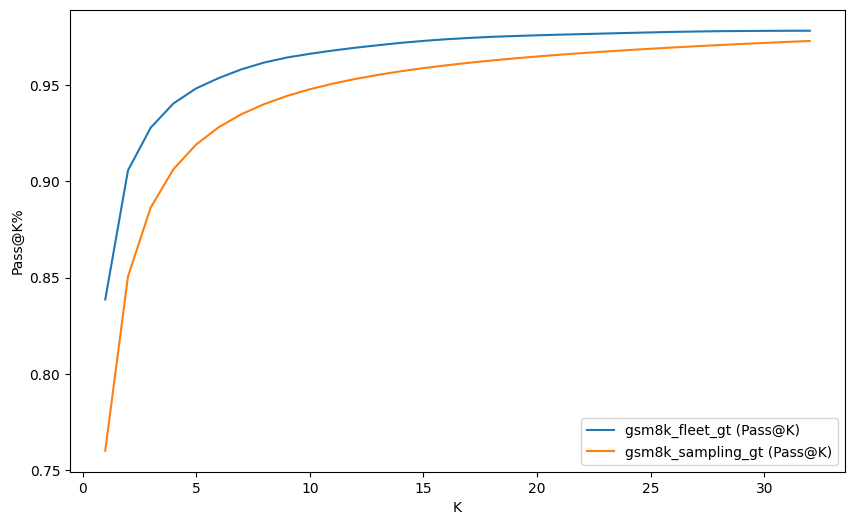

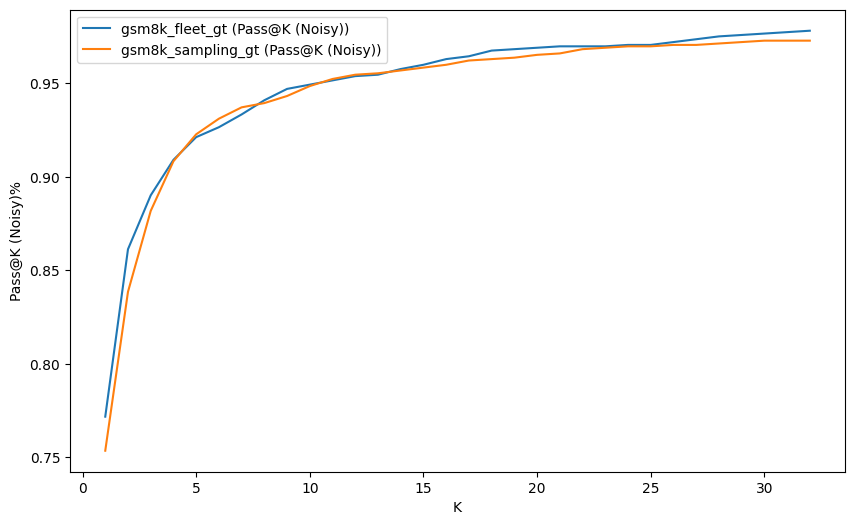

In [16]:
plot_metrics(gsm8k_gt)

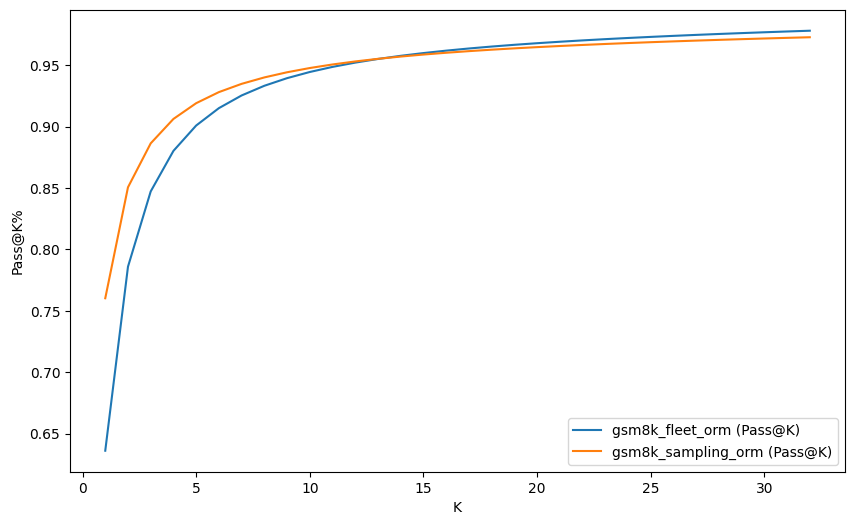

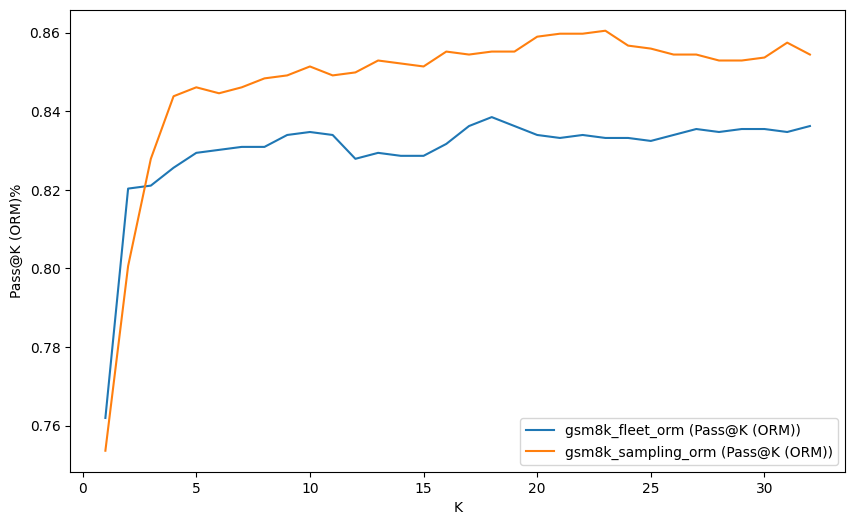

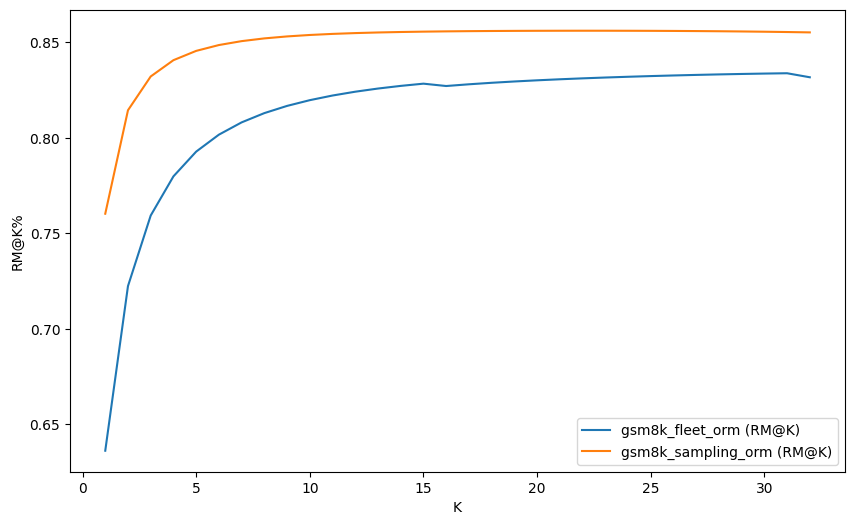

In [17]:
plot_metrics(gsm8k_orm)

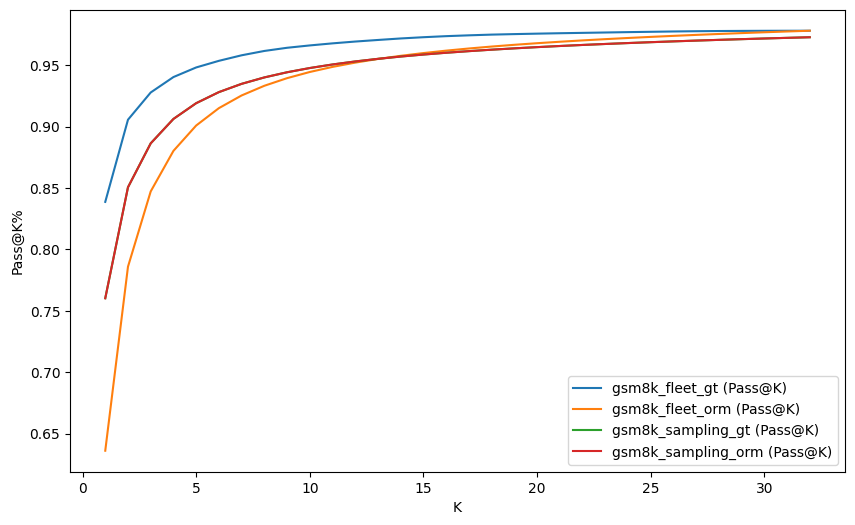

In [18]:
plot_metrics(gsm8k)

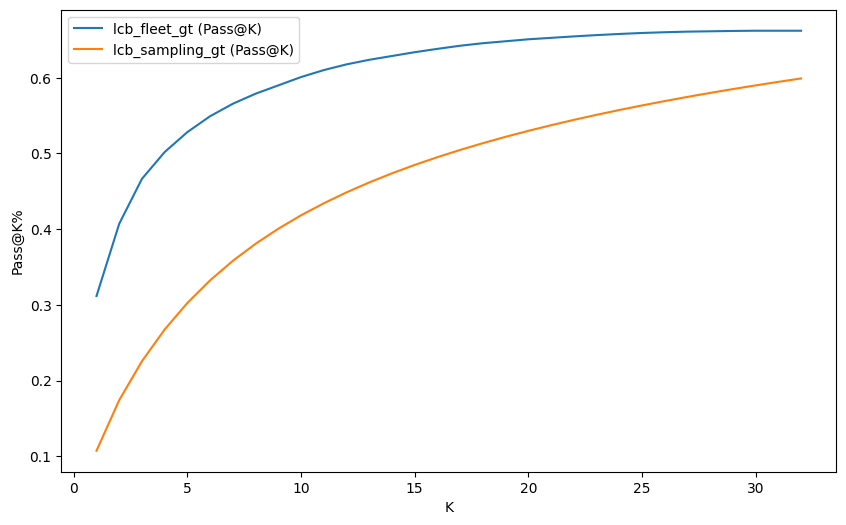

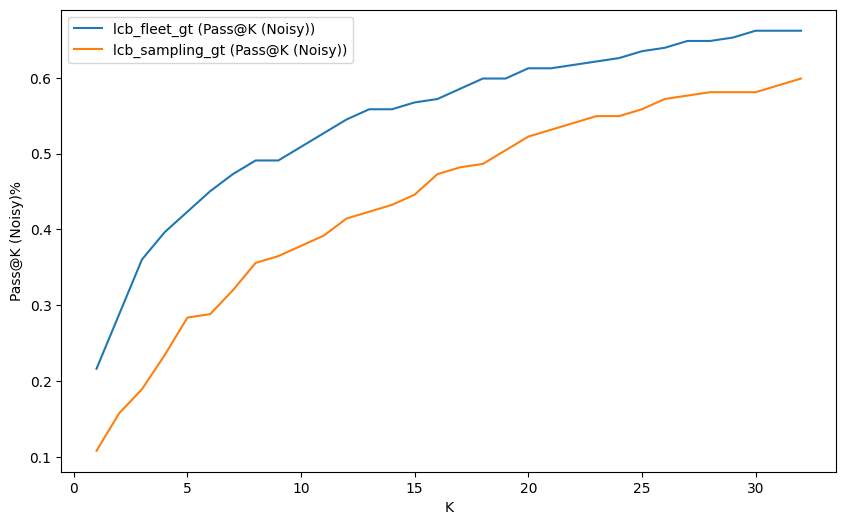

In [19]:
plot_metrics(lcb_gt)

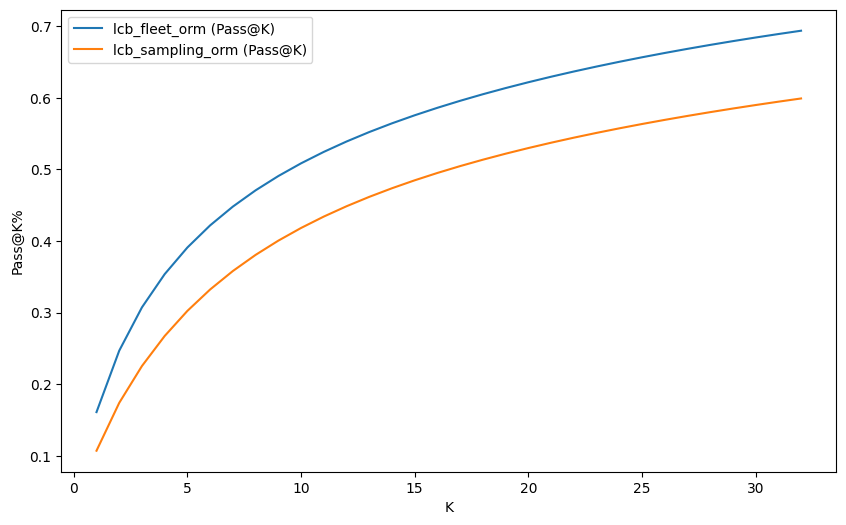

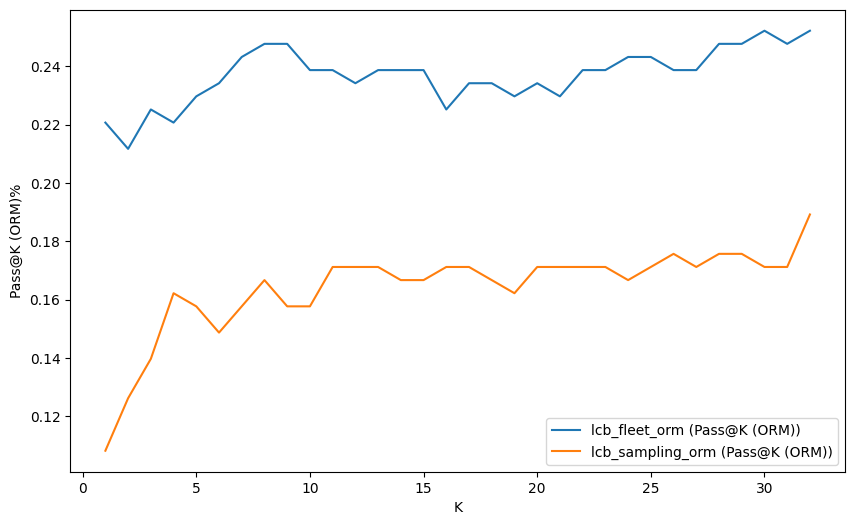

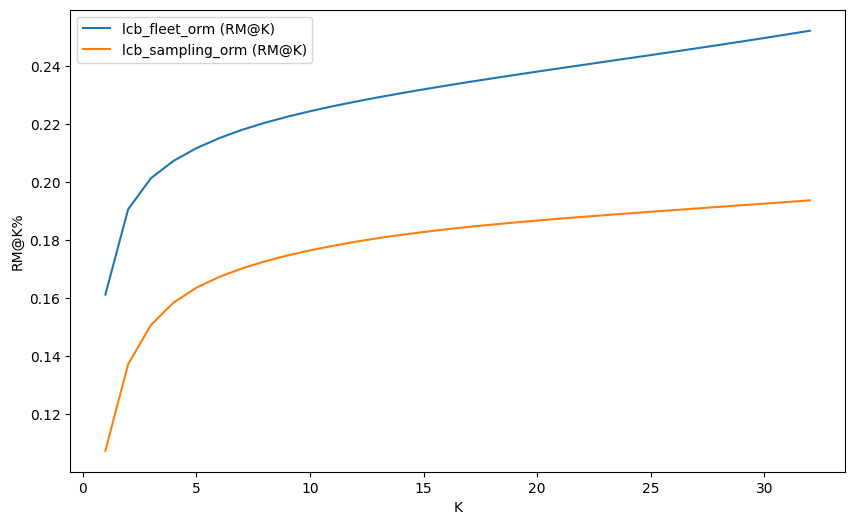

In [20]:
plot_metrics(lcb_orm)

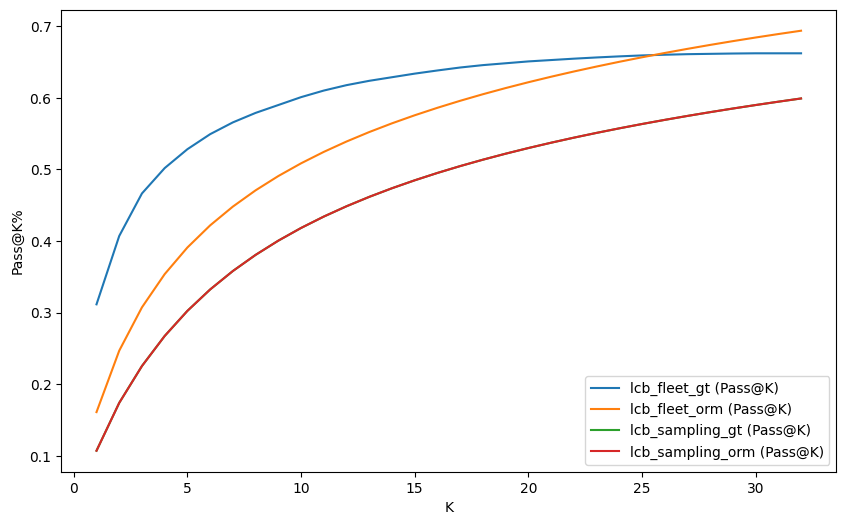

In [21]:
plot_metrics(lcb)

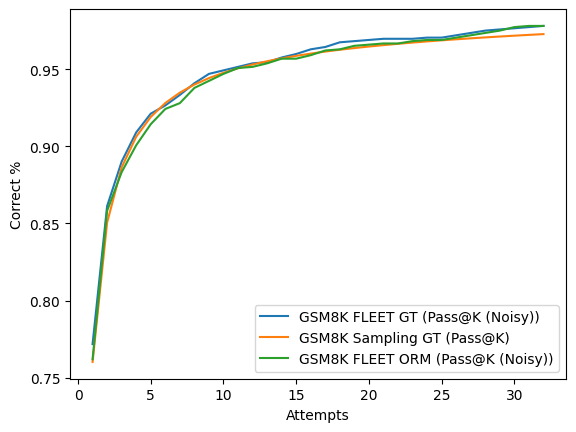

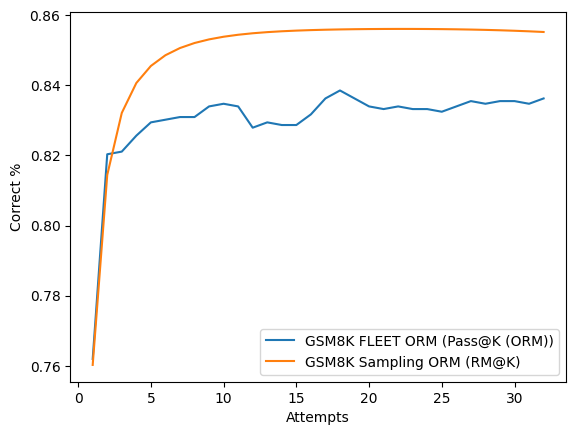

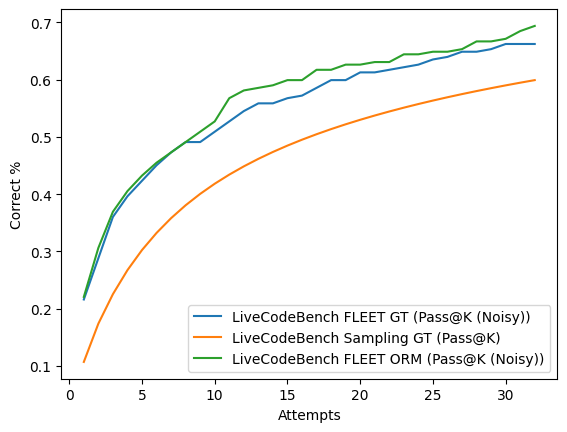

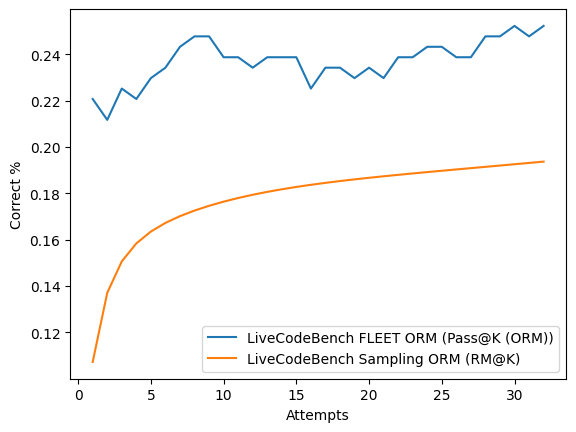

In [23]:
ax, _, _ = plot_metric('GSM8K FLEET GT', all_results['gsm8k_fleet_gt'][0], 'Pass@K (Noisy)')
plot_metric('GSM8K Sampling GT', all_results['gsm8k_sampling_gt'][0], 'Pass@K', ax)
plot_metric('GSM8K FLEET ORM', all_results['gsm8k_fleet_orm'][0], 'Pass@K (Noisy)', ax)
plt.ylabel("Correct %")
plt.xlabel("Attempts")
plt.savefig('gsm8k_gt.png')
plt.show()

ax, _, _ = plot_metric('GSM8K FLEET ORM', all_results['gsm8k_fleet_orm'][0], 'Pass@K (ORM)')
plot_metric('GSM8K Sampling ORM', all_results['gsm8k_sampling_orm'][0], 'RM@K', ax)
plt.ylabel("Correct %")
plt.xlabel("Attempts")
plt.savefig('gsm8k_orm.png')
plt.show()

ax, _, _ = plot_metric('LiveCodeBench FLEET GT', all_results['lcb_fleet_gt'][0], 'Pass@K (Noisy)')
plot_metric('LiveCodeBench Sampling GT', all_results['lcb_sampling_gt'][0], 'Pass@K', ax)
plot_metric('LiveCodeBench FLEET ORM', all_results['lcb_fleet_orm'][0], 'Pass@K (Noisy)', ax)
plt.ylabel("Correct %")
plt.xlabel("Attempts")
plt.savefig('lcb_gt.png')
plt.show()

ax, _, _ = plot_metric('LiveCodeBench FLEET ORM', all_results['lcb_fleet_orm'][0], 'Pass@K (ORM)')
plot_metric('LiveCodeBench Sampling ORM', all_results['lcb_sampling_orm'][0], 'RM@K', ax)
plt.ylabel("Correct %")
plt.xlabel("Attempts")
plt.savefig('lcb_orm.png')
plt.show()